In [2]:
import pandas as pd 
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Stock Price Data

In [3]:
# collection of stock price data
import yfinance as yf

ticker = "BMRI.JK" 
stock = yf.download(ticker, start="2019-01-01", end="2025-01-31")

stock.to_csv("BMRI_historical.csv")
stock 


Initial cleaning & formatting

In [37]:
stock = pd.read_csv('BMRI_historical.csv')
stock

,Price,Close,High,Low,Open,Volume
0,Ticker,BMRI.JK,BMRI.JK,BMRI.JK,BMRI.JK,BMRI.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,2581.069091796875,2581.069091796875,2581.069091796875,2581.069091796875,0
3,2019-01-02,2563.570068359375,2589.8182260558874,2537.3219106628626,2589.8182260558874,45319200
4,2019-01-03,2511.073974609375,2572.3196813071645,2484.8258145960367,2546.071521293826,74174000
...,...,...,...,...,...,...
1484,2025-01-21,5496.97705078125,5610.550956789127,5474.2622695796745,5542.406613184401,115355900
1485,2025-01-22,5587.83642578125,5633.265990218496,5542.406861344004,5587.83642578125,117929800
1486,2025-01-23,5610.55126953125,5724.125181869939,5610.55126953125,5633.266051998988,120893700
1487,2025-01-24,5565.12158203125,5678.695491868622,5565.12158203125,5678.695491868622,96161800


In [38]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1489 entries, 0 to 1488
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1489 non-null   object
 1   Close   1488 non-null   object
 2   High    1488 non-null   object
 3   Low     1488 non-null   object
 4   Open    1488 non-null   object
 5   Volume  1488 non-null   object
dtypes: object(6)
memory usage: 69.9+ KB


In [39]:
stock = stock.drop([0,1])
stock = stock.rename(columns={"Price": "Date", "Close":"Stock Price", 
                              "High":"Stock High", "Low":"Stock Low", 
                              "Open":"Stock Open"})
stock = stock.drop(columns=['Volume'])

# Konversi kolom tertentu ke float
stock["Stock Open"] = stock["Stock Open"].astype(float)
stock["Stock Price"] = stock["Stock Price"].astype(float)
stock["Stock Low"] = stock["Stock Low"].astype(float)
stock["Stock High"] = stock["Stock High"].astype(float)
stock['Date'] = pd.to_datetime(stock['Date'])  # Konversi ke datetime


stock

,Date,Stock Price,Stock High,Stock Low,Stock Open
2,2019-01-01,2581.069092,2581.069092,2581.069092,2581.069092
3,2019-01-02,2563.570068,2589.818226,2537.321911,2589.818226
4,2019-01-03,2511.073975,2572.319681,2484.825815,2546.071521
5,2019-01-04,2607.317383,2607.317383,2502.324737,2511.074124
6,2019-01-07,2598.567871,2651.064192,2598.567871,2624.816031
...,...,...,...,...,...
1484,2025-01-21,5496.977051,5610.550957,5474.262270,5542.406613
1485,2025-01-22,5587.836426,5633.265990,5542.406861,5587.836426
1486,2025-01-23,5610.551270,5724.125182,5610.551270,5633.266052
1487,2025-01-24,5565.121582,5678.695492,5565.121582,5678.695492


In [40]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 2 to 1488
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1487 non-null   datetime64[ns]
 1   Stock Price  1487 non-null   float64       
 2   Stock High   1487 non-null   float64       
 3   Stock Low    1487 non-null   float64       
 4   Stock Open   1487 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 58.2 KB


In [41]:
stock.isna().sum()

Date           0
Stock Price    0
Stock High     0
Stock Low      0
Stock Open     0
dtype: int64

In [42]:
import plotly.express as px

fig = px.line(stock, x='Date', y='Stock Price', title='BMRI Stock Price 2019-2025', markers=True)
fig.show()

C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [43]:
import plotly.express as px

fig = px.line(stock, x='Date', y='Stock High', title='High Price per Day', markers=True)
fig.show()

C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [44]:
import plotly.express as px

fig = px.line(stock, x='Date', y='Stock Low', title='Low Price per Day', markers=True)
fig.show()

C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [45]:
import plotly.express as px

fig = px.line(stock, x='Date', y='Stock Open', title='Open Price per Day', markers=True)
fig.show()

C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [46]:
stock.duplicated().sum()

0

In [47]:
numeric_df = stock.select_dtypes(include=['number'])
numeric_df.describe()

,Stock Price,Stock High,Stock Low,Stock Open
count,1487.000000,1487.000000,1487.000000,1487.000000
mean,3574.194215,3618.396665,3531.045417,3576.402166
std,1386.959307,1400.409864,1373.899771,1386.208016
min,1411.886963,1442.250123,1389.114593,1427.068630
25%,2495.472412,2537.322260,2474.861295,2504.960787
50%,2872.284424,2890.349337,2835.751063,2865.188248
75%,4624.458008,4678.482296,4548.824467,4656.872435
max,6769.004883,6859.863882,6723.575195,6769.004757


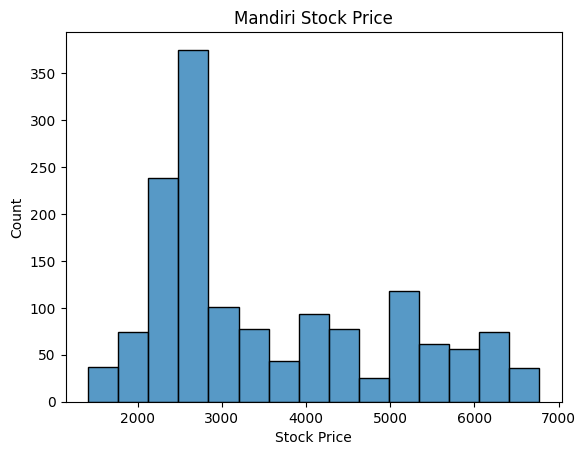

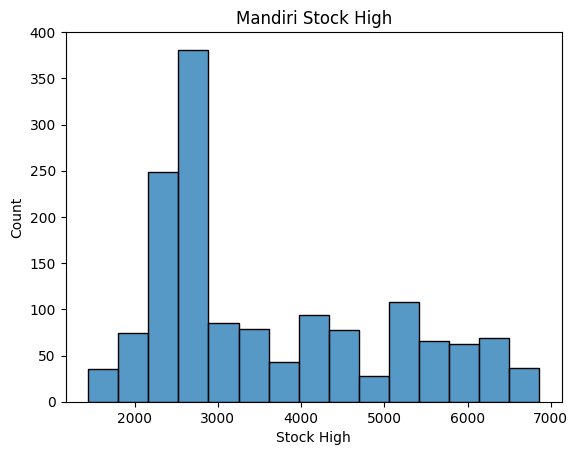

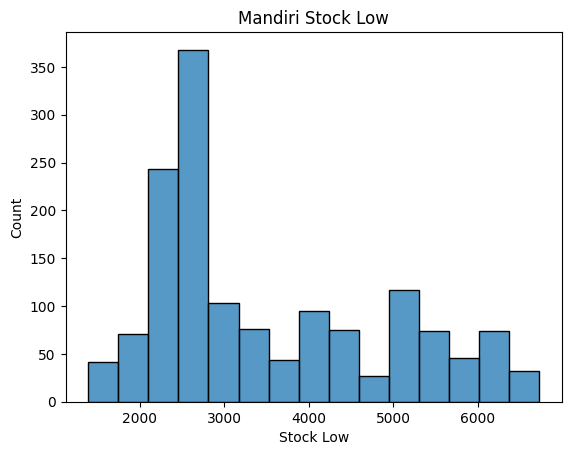

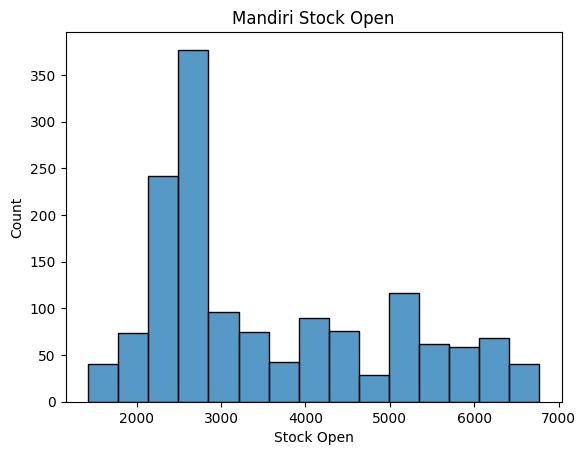

In [48]:
for i in numeric_df :
    sns.histplot(numeric_df[i])
    plt.title('Mandiri '+ i)
    plt.show()

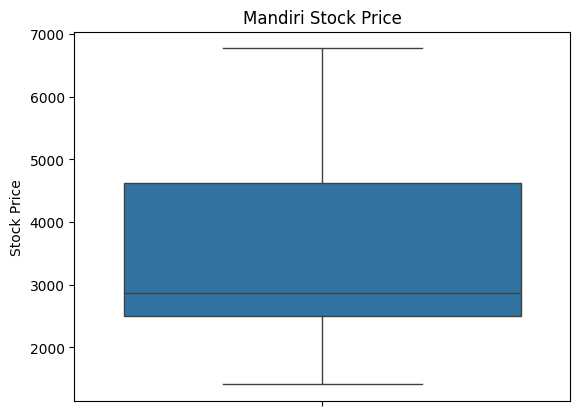

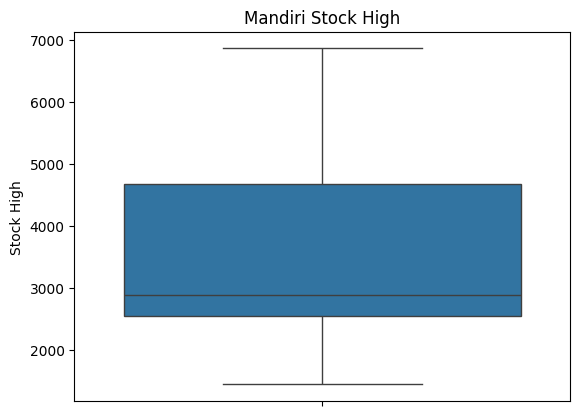

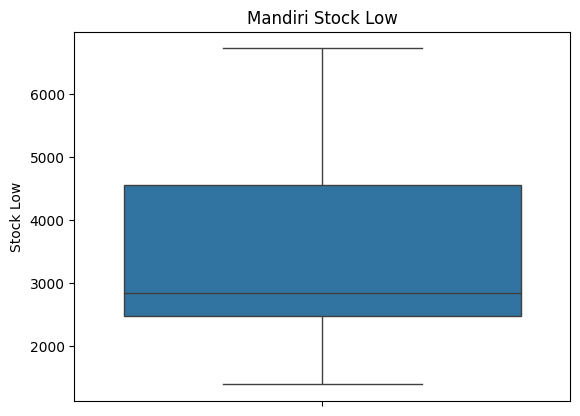

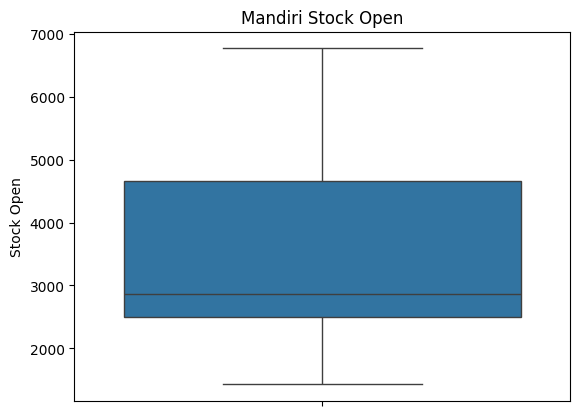

In [49]:
for i in numeric_df :
    sns.boxplot(numeric_df[i])
    plt.title('Mandiri ' + i)
    plt.show()

# Inflation

In [50]:
inflasi = pd.read_excel ('Data Inflasi.xlsx')
inflasi

,No,Periode,Data Inflasi
0,1,Januari 2025,0.76 %
1,2,Desember 2024,1.57 %
2,3,November 2024,1.55 %
3,4,Oktober 2024,1.71 %
4,5,September 2024,1.84 %
...,...,...,...
68,69,Mei 2019,3.32 %
69,70,April 2019,2.83 %
70,71,Maret 2019,2.48 %
71,72,Februari 2019,2.57 %


In [51]:
inflasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   No            73 non-null     int64 
 1   Periode       73 non-null     object
 2   Data Inflasi  73 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.8+ KB


In [52]:
inflasi.rename(columns={'Periode' : 'Date', 
                                 'Data Inflasi' : 'Inflasi'},inplace=True)

inflasi = inflasi.drop(columns=['No'])

# Mapping nama bulan Indonesia ke Inggris
month_mapping = {
    'Januari': 'January', 'Februari': 'February', 'Maret': 'March',
    'April': 'April', 'Mei': 'May', 'Juni': 'June',
    'Juli': 'July', 'Agustus': 'August', 'September': 'September',
    'Oktober': 'October', 'November': 'November', 'Desember': 'December'
}

# Mengganti nama bulan ke bahasa Inggris
inflasi['Date'] = inflasi['Date'].replace(month_mapping, regex=True)

# Konversi ke format datetime (defaultnya YYYY-MM-DD dengan tanggal 1)
inflasi['Date'] = pd.to_datetime(inflasi['Date'], format='%B %Y')

# Mengubah format 
inflasi['Inflasi'] = inflasi['Inflasi'].str.replace('%', '').astype(float) / 100

inflasi

,Date,Inflasi
0,2025-01-01,0.0076
1,2024-12-01,0.0157
2,2024-11-01,0.0155
3,2024-10-01,0.0171
4,2024-09-01,0.0184
...,...,...
68,2019-05-01,0.0332
69,2019-04-01,0.0283
70,2019-03-01,0.0248
71,2019-02-01,0.0257


In [53]:
inflasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     73 non-null     datetime64[ns]
 1   Inflasi  73 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.3 KB


In [54]:
inflasi[['Inflasi']].describe()

,Inflasi
count,73.000000
mean,0.027753
std,0.012395
min,0.007600
25%,0.016800
50%,0.026400
75%,0.033200
max,0.059500


In [55]:
inflasi.isna().sum()

Date       0
Inflasi    0
dtype: int64

In [56]:
inflasi.duplicated().sum()

0

In [57]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(inflasi, x='Date', y='Inflasi', title='Inflation', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



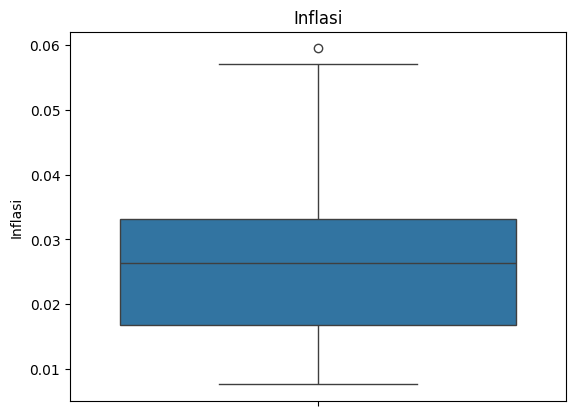

In [58]:
sns.boxplot(inflasi['Inflasi'])
plt.title("Inflasi")
plt.show()

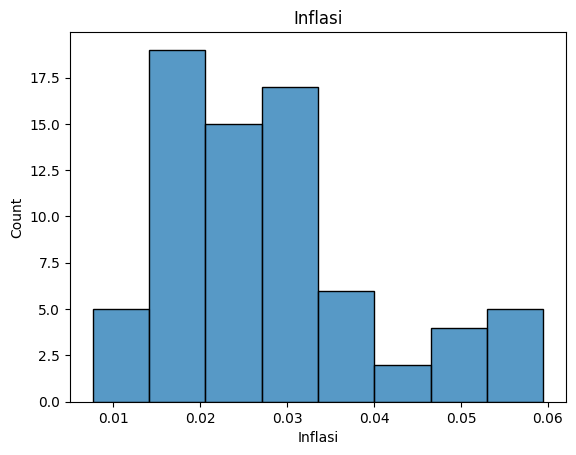

In [59]:
sns.histplot(inflasi['Inflasi'])
plt.title('Inflasi')
plt.show()

# Currency Exchange Data

In [60]:
# Collection of Currency Exchange Data
import yfinance as yf

ticker = "USDIDR=X"  
exchange = yf.download(ticker, start="2019-01-01", end="2025-01-31")

exchange.to_csv("USDIDR_historical.csv")

print(exchange.head())


C:\Users\zakyf\AppData\Local\Temp\ipykernel_27104\1178423829.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Price              Close     High           Low          Open   Volume
Ticker          USDIDR=X USDIDR=X      USDIDR=X      USDIDR=X USDIDR=X
Date                                                                  
2019-01-01  14460.000000  14460.0  14460.000000  14460.000000        0
2019-01-02  14460.000000  14513.0  14373.000000  14460.000000        0
2019-01-03  14409.700195  14502.5  14367.900391  14409.700195        0
2019-01-04  14375.400391  14403.0  14211.000000  14375.400391        0
2019-01-07  14267.000000  14263.0  14008.000000  14263.000000        0


In [61]:
exchange = pd.read_csv("USDIDR_historical.csv")
exchange

,Price,Close,High,Low,Open,Volume
0,Ticker,USDIDR=X,USDIDR=X,USDIDR=X,USDIDR=X,USDIDR=X
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,14460.0,14460.0,14460.0,14460.0,0
3,2019-01-02,14460.0,14513.0,14373.0,14460.0,0
4,2019-01-03,14409.7001953125,14502.5,14367.900390625,14409.7001953125,0
...,...,...,...,...,...,...
1583,2025-01-24,16230.900390625,16234.0,16090.400390625,16230.900390625,0
1584,2025-01-27,16164.900390625,16234.0,16141.0,16164.900390625,0
1585,2025-01-28,16155.599609375,16246.0,16140.099609375,16155.599609375,0
1586,2025-01-29,15881.2001953125,16269.2998046875,15960.599609375,15881.2001953125,0


In [62]:
exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1588 entries, 0 to 1587
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1588 non-null   object
 1   Close   1587 non-null   object
 2   High    1587 non-null   object
 3   Low     1587 non-null   object
 4   Open    1587 non-null   object
 5   Volume  1587 non-null   object
dtypes: object(6)
memory usage: 74.6+ KB


In [63]:
exchange = exchange.drop([0,1])
exchange = exchange.drop(columns=['Volume','High','Low','Open'])
exchange = exchange.rename(columns={'Price' : 'Date', 'Close' : 'Exchange Price'})

exchange["Exchange Price"] = exchange["Exchange Price"].astype(float) # Konversi ke float
exchange['Date'] = pd.to_datetime(exchange['Date'])  # Konversi ke datetime

exchange

,Date,Exchange Price
2,2019-01-01,14460.000000
3,2019-01-02,14460.000000
4,2019-01-03,14409.700195
5,2019-01-04,14375.400391
6,2019-01-07,14267.000000
...,...,...
1583,2025-01-24,16230.900391
1584,2025-01-27,16164.900391
1585,2025-01-28,16155.599609
1586,2025-01-29,15881.200195


In [64]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(exchange, x='Date', y='Exchange Price', title='Exchange', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [65]:
exchange.isna().sum()

Date              0
Exchange Price    0
dtype: int64

In [66]:
exchange.duplicated().sum()

0

In [67]:
exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1586 entries, 2 to 1587
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1586 non-null   datetime64[ns]
 1   Exchange Price  1586 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 24.9 KB


In [68]:
exchange[['Exchange Price']].describe()

,Exchange Price
count,1586.000000
mean,14837.977412
std,710.574814
min,13213.240234
25%,14251.654297
50%,14652.887207
75%,15449.500000
max,16504.800781


In [69]:
numeric_df = exchange.select_dtypes(include=['number'])
numeric_df

,Exchange Price
2,14460.000000
3,14460.000000
4,14409.700195
5,14375.400391
6,14267.000000
...,...
1583,16230.900391
1584,16164.900391
1585,16155.599609
1586,15881.200195


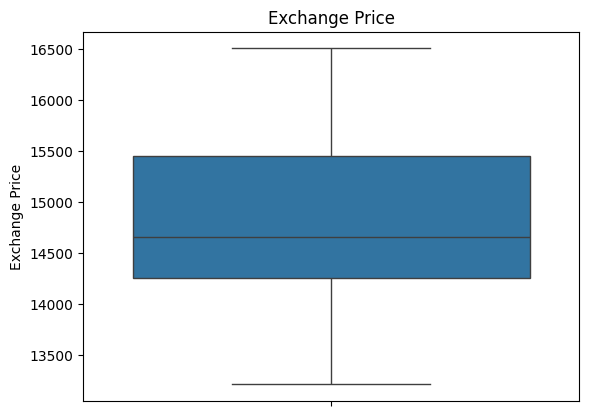

In [70]:
for i in numeric_df :
    sns.boxplot(numeric_df[i])
    plt.title(i)
    plt.show()

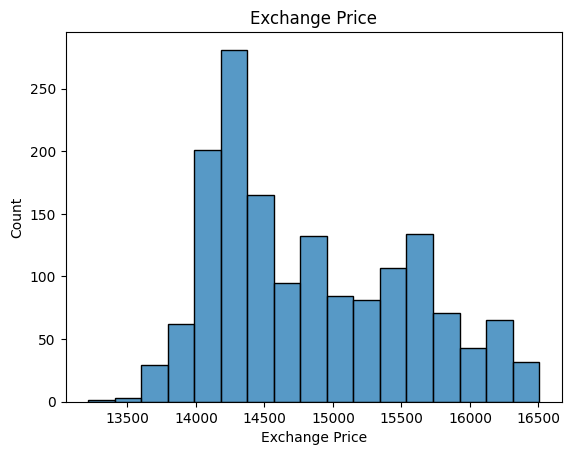

In [71]:
for i in numeric_df :
    sns.histplot(numeric_df[i])
    plt.title(i)
    plt.show()

# Sentiment Analysis

In [2]:
# Lokasi folder
folder_path = "your comments data folder path/*.csv"

# Membaca semua file CSV di folder
all_files = glob.glob(folder_path)
list_df = [pd.read_csv(file) for file in all_files]

# Menggabungkan semua DataFrame menjadi satu
twt = pd.concat(list_df, axis=0, ignore_index=True)
twt

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1871737823587713112,Wed Dec 25 02:00:47 +0000 2024,771,#어섬희선물 Merry Christmas *⭐️ꔛ #박서준 #ParkSeoJun #...,1871737823587713112,https://pbs.twimg.com/ext_tw_video_thumb/18717...,NaN,et,NaN,34,12,281,https://x.com/awesome_ent_/status/187173782358...,1670673953038422016,awesome_ent_
1,1869300797177315622,Wed Dec 18 08:36:54 +0000 2024,69,[Making Film with Bank Mandiri] @ bankmandiri ...,1869300797177315622,https://pbs.twimg.com/ext_tw_video_thumb/18693...,NaN,en,NaN,0,0,14,https://x.com/jenny061215/status/1869300797177...,569628565,jenny061215
2,1868921060789572027,Tue Dec 17 07:27:58 +0000 2024,1,Satu lagi keberhasilan oleh BUMN khususnya Ban...,1868921060789572027,https://pbs.twimg.com/ext_tw_video_thumb/18689...,NaN,in,"Mojokerto, Jawa Timur",0,1,0,https://x.com/infomjkt/status/1868921060789572027,2916804137,infomjkt
3,1869243122926195139,Wed Dec 18 04:47:44 +0000 2024,92,[Behind the Scene] @ bankmandiri 2024.12.18 20...,1869243122926195139,https://pbs.twimg.com/ext_tw_video_thumb/18692...,NaN,en,NaN,0,0,19,https://x.com/jenny061215/status/1869243122926...,569628565,jenny061215
4,1871868401154711992,Wed Dec 25 10:39:39 +0000 2024,13,E-money 1st Edition E-money 2nd Edition Debit ...,1871868401154711992,https://pbs.twimg.com/media/Gfo2YjqaMAAUFDK.jpg,NaN,en,Wonderland,0,1,2,https://x.com/_tooweaktospeak/status/187186840...,1088035247592108035,_tooweaktospeak
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4557,1524302257147506688,Wed May 11 08:15:52 +0000 2022,321,Kalo bener ini orang kaya mendadak :) Modal se...,1524302257147506688,https://pbs.twimg.com/media/FSdofrIagAE7H_8.png,NaN,in,Bandung ♥,16,62,62,https://x.com/WahRusuh/status/1524302257147506688,376235842,WahRusuh
4558,1865307341312397692,Sat Dec 07 08:08:20 +0000 2024,5,Inilah 20 saham terbesar di IDX versi market c...,1865307341312397692,https://pbs.twimg.com/ext_tw_video_thumb/18653...,NaN,in,Indonesia,0,0,1,https://x.com/Mandiri_OLT/status/1865307341312...,148198201,Mandiri_OLT
4559,1376544684726648835,Mon Mar 29 14:40:02 +0000 2021,25,Selasa 30 Maret 2021 Saham PT Zyrexindo Mandir...,1376544684726648835,https://pbs.twimg.com/media/Exp4FvJUUA02RdC.jpg,NaN,in,"Jakarta, Indonesia",4,4,4,https://x.com/IDX_BEI/status/1376544684726648835,161183813,IDX_BEI
4560,1492094815114199040,Fri Feb 11 11:15:00 +0000 2022,650,Syekh Romadhon Al-Buthi sampai terenyuh mengis...,1492094815114199040,https://pbs.twimg.com/media/FLTpfkuUcAEL9FV.jpg,NaN,in,Indonesia,6,5,158,https://x.com/sanad__media/status/149209481511...,1246788004460429312,sanad__media


In [3]:
twt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4562 entries, 0 to 4561
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      4562 non-null   int64 
 1   created_at               4562 non-null   object
 2   favorite_count           4562 non-null   int64 
 3   full_text                4562 non-null   object
 4   id_str                   4562 non-null   int64 
 5   image_url                2035 non-null   object
 6   in_reply_to_screen_name  314 non-null    object
 7   lang                     4562 non-null   object
 8   location                 1569 non-null   object
 9   quote_count              4562 non-null   int64 
 10  reply_count              4562 non-null   int64 
 11  retweet_count            4562 non-null   int64 
 12  tweet_url                4562 non-null   object
 13  user_id_str              4562 non-null   int64 
 14  username                 2132 non-null  

In [4]:
twt['Date'] = pd.to_datetime(twt['created_at'], format='%a %b %d %H:%M:%S %z %Y').dt.strftime('%Y-%m-%d')
twt['Date'] = pd.to_datetime(twt['Date'])
twt = twt[['Date', 'id_str','full_text']]
twt

,Date,id_str,full_text
0,2024-12-25,1871737823587713112,#어섬희선물 Merry Christmas *⭐️ꔛ #박서준 #ParkSeoJun #...
1,2024-12-18,1869300797177315622,[Making Film with Bank Mandiri] @ bankmandiri ...
2,2024-12-17,1868921060789572027,Satu lagi keberhasilan oleh BUMN khususnya Ban...
3,2024-12-18,1869243122926195139,[Behind the Scene] @ bankmandiri 2024.12.18 20...
4,2024-12-25,1871868401154711992,E-money 1st Edition E-money 2nd Edition Debit ...
...,...,...,...
4557,2022-05-11,1524302257147506688,Kalo bener ini orang kaya mendadak :) Modal se...
4558,2024-12-07,1865307341312397692,Inilah 20 saham terbesar di IDX versi market c...
4559,2021-03-29,1376544684726648835,Selasa 30 Maret 2021 Saham PT Zyrexindo Mandir...
4560,2022-02-11,1492094815114199040,Syekh Romadhon Al-Buthi sampai terenyuh mengis...


In [5]:
twt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4562 entries, 0 to 4561
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4562 non-null   datetime64[ns]
 1   id_str     4562 non-null   int64         
 2   full_text  4562 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 107.0+ KB


In [6]:
twt.isna().sum()

Date         0
id_str       0
full_text    0
dtype: int64

In [7]:
twt.duplicated().sum()

1549

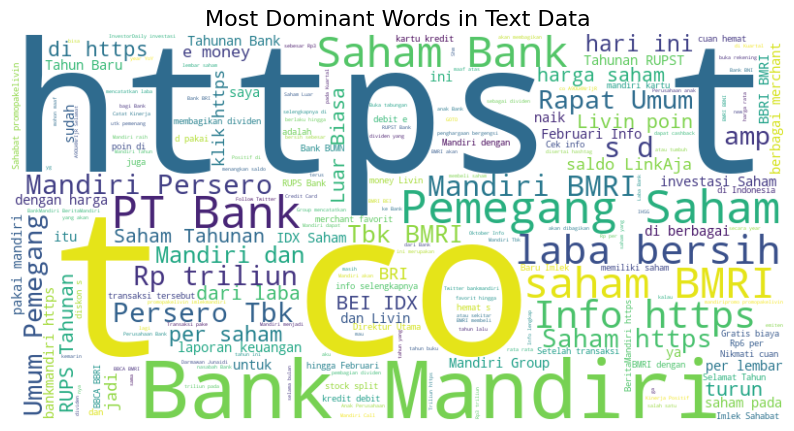

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(twt['full_text'].astype(str))  # gabungkan semua teks jadi satu string
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Dominant Words in Text Data', fontsize=16)
plt.show()


In [9]:
# Preprocessing

twt = twt.drop_duplicates(subset=['id_str'])
twt.duplicated().sum()

0

In [10]:
twt = twt.sort_values('Date', ascending = True)
twt

,Date,id_str,full_text
4549,2019-01-02,1080349841388036096,Di Jakarta kami menyebutnya Pedagang Kecil Man...
341,2019-01-03,1080748764317372416,SMI mendapat hadiah menteri terbaik dr The Ban...
3725,2019-01-07,1082261749842100224,Kartika Wirjoatmodjo: hanya ada satu keputusan...
3273,2019-01-07,1082118790224044032,PT Bank Mandiri (Persero) Tbk (BMRI) menyeleng...
739,2019-01-10,1083506017567043584,[TERKINI] #AWANInews #FajarAWANI ADUN Semenyih...
...,...,...,...
725,2025-01-26,1883498720471445557,Yang menarik NKK/BKK tersebut diterapkan sejak...
3024,2025-01-28,1884257031705747920,@SUNGCHANN_ @SUNGCHANN_ Hi Sahabat @SUNGCHANN_...
1635,2025-01-28,1884247055763226901,Agus Dwi Handaya Direktur PT Bank Mandiri (Per...
2135,2025-01-29,1884572891485966505,Deposito BPR Deposito yg BERANI ngasih bunga 6...


In [106]:
teks = twt[['Date','full_text']]
teks = teks.dropna(subset=['full_text'])
teks

,Date,full_text
4549,2019-01-02,Di Jakarta kami menyebutnya Pedagang Kecil Man...
341,2019-01-03,SMI mendapat hadiah menteri terbaik dr The Ban...
3725,2019-01-07,Kartika Wirjoatmodjo: hanya ada satu keputusan...
3273,2019-01-07,PT Bank Mandiri (Persero) Tbk (BMRI) menyeleng...
739,2019-01-10,[TERKINI] #AWANInews #FajarAWANI ADUN Semenyih...
...,...,...
725,2025-01-26,Yang menarik NKK/BKK tersebut diterapkan sejak...
3024,2025-01-28,@SUNGCHANN_ @SUNGCHANN_ Hi Sahabat @SUNGCHANN_...
1635,2025-01-28,Agus Dwi Handaya Direktur PT Bank Mandiri (Per...
2135,2025-01-29,Deposito BPR Deposito yg BERANI ngasih bunga 6...


In [41]:
#Preprocessing full text
import string
import re


def remove_single_char_words(text):
    # Pisahkan teks menjadi kata-kata
    words = text.split()
    # Hanya pertahankan kata yang panjangnya lebih dari 1 karakter
    filtered_words = [word for word in words if len(word) > 3]
    # Gabungkan kembali menjadi satu string
    return ' '.join(filtered_words)


def filteringText(text):
    if text is None:  # Check if the input is None
        return ''  # Return empty string if it is None

    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = text.replace('\n', ' ')
    text = remove_single_char_words(text)
    text = text.strip(' ')

    return text


data_slang = pd.read_excel('kamus_slangword.xlsx')
def replace_slang(text):
    res = ''
    for item in text.split():
        if item in data_slang.slang.values:
            res += data_slang[data_slang['slang'] == item]['formal'].iloc[0]
        else:
            res += item
        res += ' '
    return res


In [42]:
#fix slangwords
teks['full_text'] = teks['full_text'].apply(replace_slang)
teks

,Date,full_text
4549,2019-01-02,Di Jakarta kami menyebutnya Pedagang Kecil Man...
341,2019-01-03,SMI mendapat hadiah menteri terbaik dari The B...
3725,2019-01-07,Kartika Wirjoatmodjo: hanya ada satu keputusan...
3273,2019-01-07,PT Bank Mandiri (Persero) Tbk (BMRI) menyeleng...
739,2019-01-10,[TERKINI] #AWANInews #FajarAWANI ADUN Semenyih...
...,...,...
725,2025-01-26,Yang menarik NKK/BKK tersebut diterapkan sejak...
3024,2025-01-28,@SUNGCHANN_ @SUNGCHANN_ Hi Sahabat @SUNGCHANN_...
1635,2025-01-28,Agus Dwi Handaya Direktur PT Bank Mandiri (Per...
2135,2025-01-29,Deposito BPR Deposito yang BERANI mengasih bun...


In [43]:
#filtering
teks['full_text'] = teks['full_text'].apply(filteringText)
teks

,Date,full_text
4549,2019-01-02,Jakarta kami menyebutnya Pedagang Kecil Mandir...
341,2019-01-03,mendapat hadiah menteri terbaik dari Banker? t...
3725,2019-01-07,Kartika Wirjoatmodjo: hanya satu keputusan dal...
3273,2019-01-07,Bank Mandiri (Persero) (BMRI) menyelenggarakan...
739,2019-01-10,[TERKINI] ADUN Semenyih Bakhtiar Mohd meningga...
...,...,...
725,2025-01-26,Yang menarik NKK/BKK tersebut diterapkan sejak...
3024,2025-01-28,Sahabat Terima kasih atas saran masukkan yang ...
1635,2025-01-28,Agus Handaya Direktur Bank Mandiri (Persero) (...
2135,2025-01-29,Deposito Deposito yang BERANI mengasih bunga t...


In [38]:
from deep_translator import GoogleTranslator
import pandas as pd

# Inisialisasi Google Translator
translator = GoogleTranslator(source='auto', target='en')

# Fungsi untuk menerjemahkan teks
def translate_text(text):
    if pd.isna(text):  # Jika cell kosong, lewati
        return ""
    return translator.translate(text)

# Terapkan fungsi translate ke kolom 'full_text'
teks['full_text'] = teks['full_text'].apply(translate_text)

# Menampilkan hasil
teks


C:\Users\zakyf\AppData\Local\Temp\ipykernel_19216\1476128948.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Inflasi'] = df['Inflasi'].fillna(method='ffill')
C:\Users\zakyf\AppData\Local\Temp\ipykernel_19216\1476128948.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['Stock Price','Stock Open','Stock High','Stock Low']] = df[['Stock Price','Stock Open','Stock High','Stock Low']].fillna(method='ffill')
C:\Users\zakyf\AppData\Local\Temp\ipykernel_19216\1476128948.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['Exchange Price', 'Exchange Open','Exchange High','Exchange Low']] = df[['Exchange Price', 'Exchange Open','Exchange High','Exchange Low']].fillna(method='ffill')


In [ ]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import unicodedata

sentiment_i_a = SentimentIntensityAnalyzer()

# Iterate over rows of the original dataframe, not the transposed version
for indexx, row in teks.iterrows():
    try:
        sentence_i = unicodedata.normalize('NFKD', row['full_text'])
        sentence_sentiment = sentiment_i_a.polarity_scores(sentence_i)
        
        # Update the dataframe with sentiment scores
        teks.at[indexx, 'Comp'] = sentence_sentiment['compound']
        teks.at[indexx, 'Negative'] = sentence_sentiment['neg']
        teks.at[indexx, 'Neutral'] = sentence_sentiment['neu']
        teks.at[indexx, 'Positive'] = sentence_sentiment['pos']
    except TypeError:
        print(teks.loc[indexx, 'full_text'])
        print(indexx)

In [40]:
import pandas as pd

teks['Date'] = pd.to_datetime(teks['Date'])

# Agregasi berdasarkan tanggal
aggregated_data = teks.groupby('Date').agg(
    mean_comp=('Comp', 'mean'),   # Rata-rata skor compound
    median_comp=('Comp', 'median'),       # Median Comp
    mean_negative=('Negative', 'mean'),  # Rata-rata Negative
    mean_neutral=('Neutral', 'mean'),    # Rata-rata Neutral
    mean_positive=('Positive', 'mean')   # Rata-rata Positive
).reset_index()

# Menampilkan hasil agregasi
aggregated_data


In [50]:
aggregated_data.to_csv('sentiment score bank mandiri')

In [76]:
aggregated_data = pd.read_csv('sentiment score bank mandiri')
aggregated_data = aggregated_data.drop(columns=['Unnamed: 0','median_comp','mean_negative','mean_neutral','mean_positive'])
aggregated_data = aggregated_data.dropna()
aggregated_data

,Date,mean_comp
0,2019-01-02,-0.599400
1,2019-01-03,0.636100
2,2019-01-07,0.000000
3,2019-01-10,0.396875
4,2019-01-14,0.510600
...,...,...
1189,2025-01-25,0.765000
1190,2025-01-26,0.318200
1191,2025-01-28,0.779700
1192,2025-01-29,0.921700


In [77]:
aggregated_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1194 non-null   object 
 1   mean_comp  1194 non-null   float64
dtypes: float64(1), object(1)
memory usage: 18.8+ KB


In [78]:
aggregated_data['Date'] = pd.to_datetime(aggregated_data['Date'])


In [79]:
df = aggregated_data
for df_merged in [inflasi, exchange, stock]:
    df = pd.merge(df_merged, df, on="Date", how="outer")

df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-01,2581.069092,2581.069092,2581.069092,2581.069092,14460.000000,0.0282,NaN
1,2019-01-02,2563.570068,2589.818226,2537.321911,2589.818226,14460.000000,NaN,-0.5994
2,2019-01-03,2511.073975,2572.319681,2484.825815,2546.071521,14409.700195,NaN,0.6361
3,2019-01-04,2607.317383,2607.317383,2502.324737,2511.074124,14375.400391,NaN,NaN
4,2019-01-07,2598.567871,2651.064192,2598.567871,2624.816031,14267.000000,NaN,0.0000
...,...,...,...,...,...,...,...,...
1869,2025-01-26,NaN,NaN,NaN,NaN,NaN,NaN,0.3182
1870,2025-01-27,NaN,NaN,NaN,NaN,16164.900391,NaN,NaN
1871,2025-01-28,NaN,NaN,NaN,NaN,16155.599609,NaN,0.7797
1872,2025-01-29,NaN,NaN,NaN,NaN,15881.200195,NaN,0.9217


In [80]:
# # Mengisi missing value pada data tipe data float atau integer tepat dengan value sebelumnya.
df['Inflasi'] = df['Inflasi'].fillna(method='ffill')
df[['Stock Price','Stock Open','Stock High','Stock Low']] = df[['Stock Price','Stock Open','Stock High','Stock Low']].fillna(method='ffill')
df['Exchange Price'] = df['Exchange Price'].fillna(method='ffill')
df['mean_comp'] = df['mean_comp'].fillna(method='ffill')
df = df.dropna()
df

C:\Users\zakyf\AppData\Local\Temp\ipykernel_27104\274686097.py:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

C:\Users\zakyf\AppData\Local\Temp\ipykernel_27104\274686097.py:3: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

C:\Users\zakyf\AppData\Local\Temp\ipykernel_27104\274686097.py:4: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

C:\Users\zakyf\AppData\Local\Temp\ipykernel_27104\274686097.py:5: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
1,2019-01-02,2563.570068,2589.818226,2537.321911,2589.818226,14460.000000,0.0282,-0.5994
2,2019-01-03,2511.073975,2572.319681,2484.825815,2546.071521,14409.700195,0.0282,0.6361
3,2019-01-04,2607.317383,2607.317383,2502.324737,2511.074124,14375.400391,0.0282,0.6361
4,2019-01-07,2598.567871,2651.064192,2598.567871,2624.816031,14267.000000,0.0282,0.0000
5,2019-01-08,2572.319824,2616.066760,2572.319824,2598.567986,14083.000000,0.0282,0.0000
...,...,...,...,...,...,...,...,...
1869,2025-01-26,5565.121582,5678.695492,5565.121582,5678.695492,16230.900391,0.0076,0.3182
1870,2025-01-27,5565.121582,5678.695492,5565.121582,5678.695492,16164.900391,0.0076,0.3182
1871,2025-01-28,5565.121582,5678.695492,5565.121582,5678.695492,16155.599609,0.0076,0.7797
1872,2025-01-29,5565.121582,5678.695492,5565.121582,5678.695492,15881.200195,0.0076,0.9217


In [82]:
df.isna().sum()

Date              0
Stock Price       0
Stock High        0
Stock Low         0
Stock Open        0
Exchange Price    0
Inflasi           0
mean_comp         0
dtype: int64

In [83]:
df.duplicated().sum()

0

In [84]:
df.to_csv('data_BMRI.csv')

In [84]:
df = pd.read_csv('data_BMRI.csv')
df

,Unnamed: 0,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Exchange High,Exchange Low,Exchange Open,Inflasi,mean_comp
0,1,2019-01-02,2563.570068,2589.818226,2537.321911,2589.818226,14460.000000,14513.000000,14373.000000,14460.000000,0.0282,-0.5994
1,2,2019-01-03,2511.073975,2572.319681,2484.825815,2546.071521,14409.700195,14502.500000,14367.900391,14409.700195,0.0282,0.6361
2,3,2019-01-04,2607.317383,2607.317383,2502.324737,2511.074124,14375.400391,14403.000000,14211.000000,14375.400391,0.0282,0.6361
3,4,2019-01-07,2598.567871,2651.064192,2598.567871,2624.816031,14267.000000,14263.000000,14008.000000,14263.000000,0.0282,0.0000
4,6,2019-01-08,2572.319824,2616.066760,2572.319824,2598.567986,14083.000000,14164.000000,13988.000000,14094.000000,0.0282,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
1868,3687,2025-01-26,5565.121582,5678.695492,5565.121582,5678.695492,16230.900391,16234.000000,16090.400391,16230.900391,0.0076,0.3182
1869,3688,2025-01-27,5565.121582,5678.695492,5565.121582,5678.695492,16164.900391,16234.000000,16141.000000,16164.900391,0.0076,0.3182
1870,3689,2025-01-28,5565.121582,5678.695492,5565.121582,5678.695492,16155.599609,16246.000000,16140.099609,16155.599609,0.0076,0.7797
1871,3691,2025-01-29,5565.121582,5678.695492,5565.121582,5678.695492,15881.200195,16269.299805,15960.599609,15881.200195,0.0076,0.9217


# LSTM

In [93]:
import pandas as pd
import numpy as np
import matplotlib
import glob
import re
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, LSTM
from keras.optimizers import Adam

In [95]:
df = pd.read_csv('data_BMRI.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-02,2563.570068,2589.818226,2537.321911,2589.818226,14460.000000,0.0282,-0.5994
1,2019-01-03,2511.073975,2572.319681,2484.825815,2546.071521,14409.700195,0.0282,0.6361
2,2019-01-04,2607.317383,2607.317383,2502.324737,2511.074124,14375.400391,0.0282,0.6361
3,2019-01-07,2598.567871,2651.064192,2598.567871,2624.816031,14267.000000,0.0282,0.0000
4,2019-01-08,2572.319824,2616.066760,2572.319824,2598.567986,14083.000000,0.0282,0.0000
...,...,...,...,...,...,...,...,...
1868,2025-01-26,5565.121582,5678.695492,5565.121582,5678.695492,16230.900391,0.0076,0.3182
1869,2025-01-27,5565.121582,5678.695492,5565.121582,5678.695492,16164.900391,0.0076,0.3182
1870,2025-01-28,5565.121582,5678.695492,5565.121582,5678.695492,16155.599609,0.0076,0.7797
1871,2025-01-29,5565.121582,5678.695492,5565.121582,5678.695492,15881.200195,0.0076,0.9217


In [96]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(df, x='Date', y='Stock Price', title='Stock Price Over Time', markers=True)
fig.show()


In [97]:
import numpy as np
import random
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error
import tensorflow as tf

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [98]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size

train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)


In [99]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [100]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [101]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)


In [102]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

n_features = len(feature_cols)

model = Sequential()
model.add(LSTM(96, input_shape=(look_back, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,              
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
81/81 [==============================] - 2s 12ms/step - loss: 0.0074 - val_loss: 0.0037
Epoch 2/100
81/81 [==============================] - 1s 9ms/step - loss: 0.0032 - val_loss: 0.0567
Epoch 3/100
81/81 [==============================] - 1s 10ms/step - loss: 0.0013 - val_loss: 0.0146
Epoch 4/100
81/81 [==============================] - 1s 9ms/step - loss: 0.0011 - val_loss: 0.0061
Epoch 5/100
81/81 [==============================] - 1s 9ms/step - loss: 9.8156e-04 - val_loss: 0.0064
Epoch 6/100
81/81 [==============================] - 1s 9ms/step - loss: 0.0013 - val_loss: 0.0114
Epoch 7/100
81/81 [==============================] - 1s 9ms/step - loss: 0.0015 - val_loss: 0.0088
Epoch 8/100
81/81 [==============================] - 1s 10ms/step - loss: 8.5615e-04 - val_loss: 0.0033
Epoch 9/100
81/81 [==============================] - 1s 9ms/step - loss: 7.1166e-04 - val_loss: 0.0034
Epoch 10/100
81/81 [==============================] - 1s 9ms/step - loss: 7.8671e-04 - val_los

81/81 [==============================] - 1s 10ms/step - loss: 6.0641e-04 - val_loss: 0.0014
Epoch 80/100
81/81 [==============================] - 1s 9ms/step - loss: 3.7755e-04 - val_loss: 0.0021
Epoch 81/100
81/81 [==============================] - 1s 9ms/step - loss: 3.5848e-04 - val_loss: 0.0023


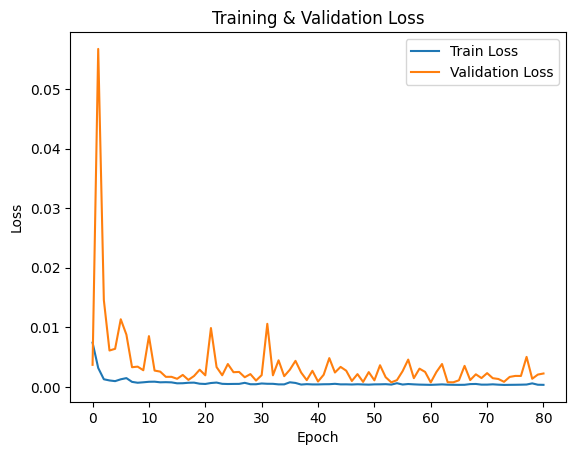

In [103]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()

In [104]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")



11/11 [==============================] - 0s 4ms/step
📊 Evaluation Metrics:
MAE  : 84.2223
MAPE : 1.42%


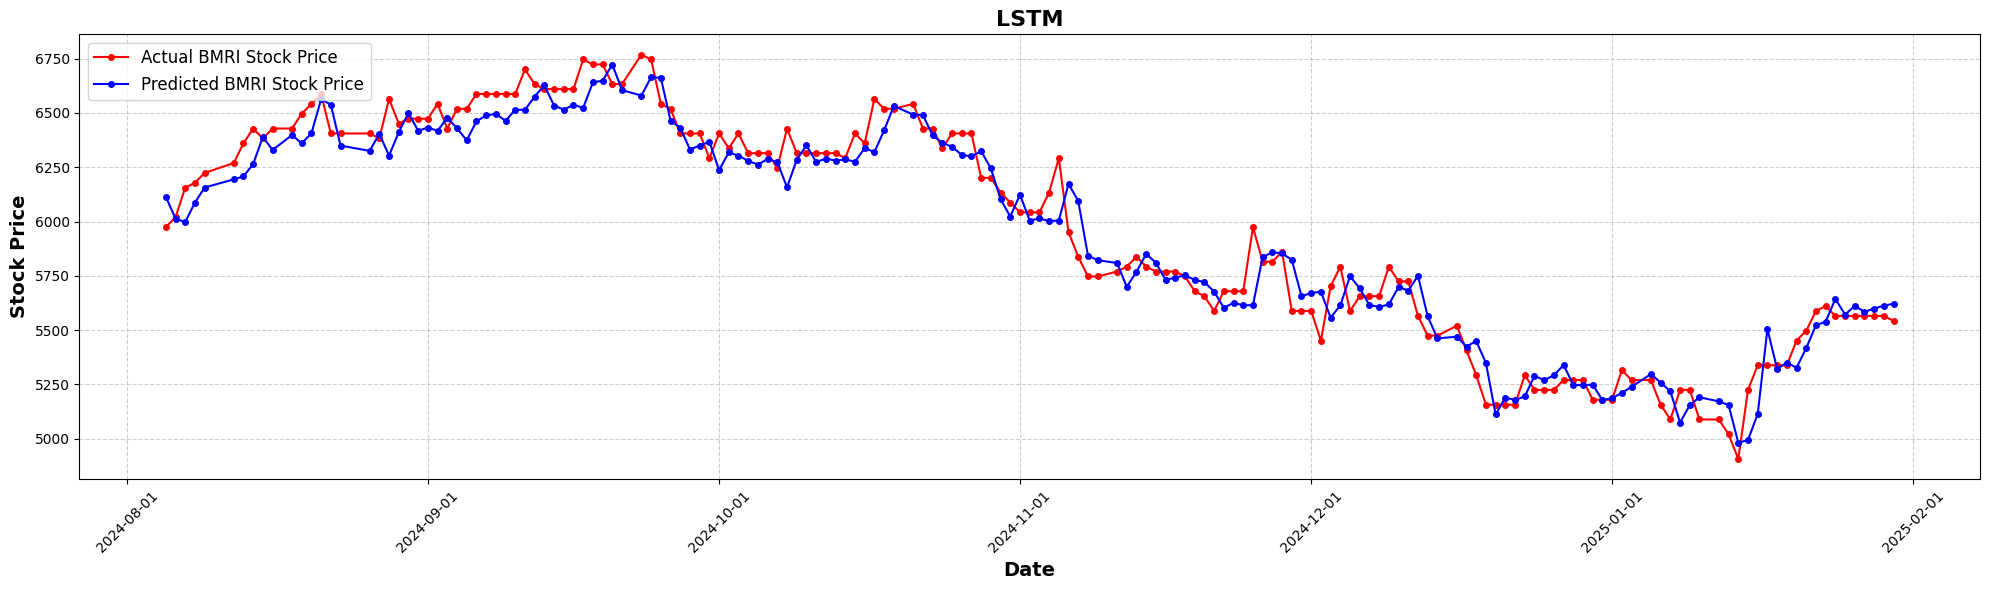

In [105]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Konversi kolom 'Date' ke format datetime jika belum
test_data['Date'] = pd.to_datetime(test_data['Date'])

offset = look_back

# Prediksi hasil model sudah di-inverse transform
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[offset:])

plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BMRI Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BMRI Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("LSTM", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


# CNN

In [123]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten
from keras.optimizers import Adam
import glob
import re

In [124]:
df = pd.read_csv('data_BMRI.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Exchange High,Exchange Low,Exchange Open,Inflasi,mean_comp
0,2019-01-02,2563.570068,2589.818226,2537.321911,2589.818226,14460.000000,14513.000000,14373.000000,14460.000000,0.0282,-0.5994
1,2019-01-03,2511.073975,2572.319681,2484.825815,2546.071521,14409.700195,14502.500000,14367.900391,14409.700195,0.0282,0.6361
2,2019-01-04,2607.317383,2607.317383,2502.324737,2511.074124,14375.400391,14403.000000,14211.000000,14375.400391,0.0282,0.6361
3,2019-01-07,2598.567871,2651.064192,2598.567871,2624.816031,14267.000000,14263.000000,14008.000000,14263.000000,0.0282,0.0000
4,2019-01-08,2572.319824,2616.066760,2572.319824,2598.567986,14083.000000,14164.000000,13988.000000,14094.000000,0.0282,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
1868,2025-01-26,5565.121582,5678.695492,5565.121582,5678.695492,16230.900391,16234.000000,16090.400391,16230.900391,0.0076,0.3182
1869,2025-01-27,5565.121582,5678.695492,5565.121582,5678.695492,16164.900391,16234.000000,16141.000000,16164.900391,0.0076,0.3182
1870,2025-01-28,5565.121582,5678.695492,5565.121582,5678.695492,16155.599609,16246.000000,16140.099609,16155.599609,0.0076,0.7797
1871,2025-01-29,5565.121582,5678.695492,5565.121582,5678.695492,15881.200195,16269.299805,15960.599609,15881.200195,0.0076,0.9217


In [125]:
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [126]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size  # Sisa untuk test

# Pisahkan data tanpa shuffle
train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)

In [127]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [128]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [129]:
# Conv1D = Lapisan dalam jaringan saraf konvolusional (CNN)

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)

# Defining CNN model for time series forecasting
n_filters = 128
kernel_size = 3
n_features = len(feature_cols)
model = Sequential()
model.add(Conv1D(filters=n_filters, kernel_size=kernel_size, activation='relu', input_shape=(look_back, n_features)))
model.add(Flatten())
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,              # berhenti kalau 20 epoch berturut-turut val_loss stagnan
    restore_best_weights=True # ambil bobot terbaik sebelum overfitting
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
81/81 [==============================] - 0s 3ms/step - loss: 0.0282 - val_loss: 0.0045
Epoch 2/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0023 - val_loss: 0.0116
Epoch 3/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0027 - val_loss: 0.0283
Epoch 4/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0030 - val_loss: 0.0201
Epoch 5/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0029 - val_loss: 0.0431
Epoch 6/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0034 - val_loss: 0.0053
Epoch 7/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0018 - val_loss: 0.0038
Epoch 8/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0020 - val_loss: 0.0024
Epoch 9/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 10/100
81/81 [==============================] - 0s 2ms/step - loss: 0.0011 - val_loss: 0.0065
Epoch 11/

81/81 [==============================] - 0s 3ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 82/100
81/81 [==============================] - 0s 2ms/step - loss: 4.6156e-04 - val_loss: 0.0024
Epoch 83/100
81/81 [==============================] - 0s 2ms/step - loss: 6.3988e-04 - val_loss: 0.0074
Epoch 84/100
81/81 [==============================] - 0s 2ms/step - loss: 5.0758e-04 - val_loss: 0.0028
Epoch 85/100
81/81 [==============================] - 0s 2ms/step - loss: 4.7205e-04 - val_loss: 0.0024
Epoch 86/100
81/81 [==============================] - 0s 2ms/step - loss: 7.0649e-04 - val_loss: 0.0063
Epoch 87/100
81/81 [==============================] - 0s 2ms/step - loss: 4.7334e-04 - val_loss: 0.0025
Epoch 88/100
81/81 [==============================] - 0s 2ms/step - loss: 6.0095e-04 - val_loss: 0.0015
Epoch 89/100
81/81 [==============================] - 0s 2ms/step - loss: 4.4445e-04 - val_loss: 0.0020
Epoch 90/100
81/81 [==============================] - 0s 2ms/step - loss: 4.3379e

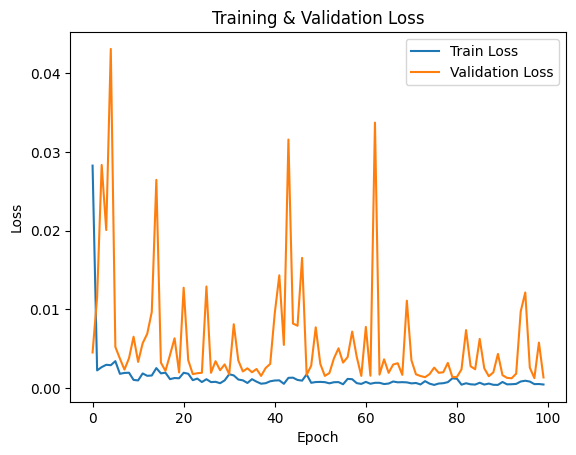

In [130]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()


In [131]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")


11/11 [==============================] - 0s 1ms/step
📊 Evaluation Metrics:
MAE  : 100.9725
MAPE : 1.72%


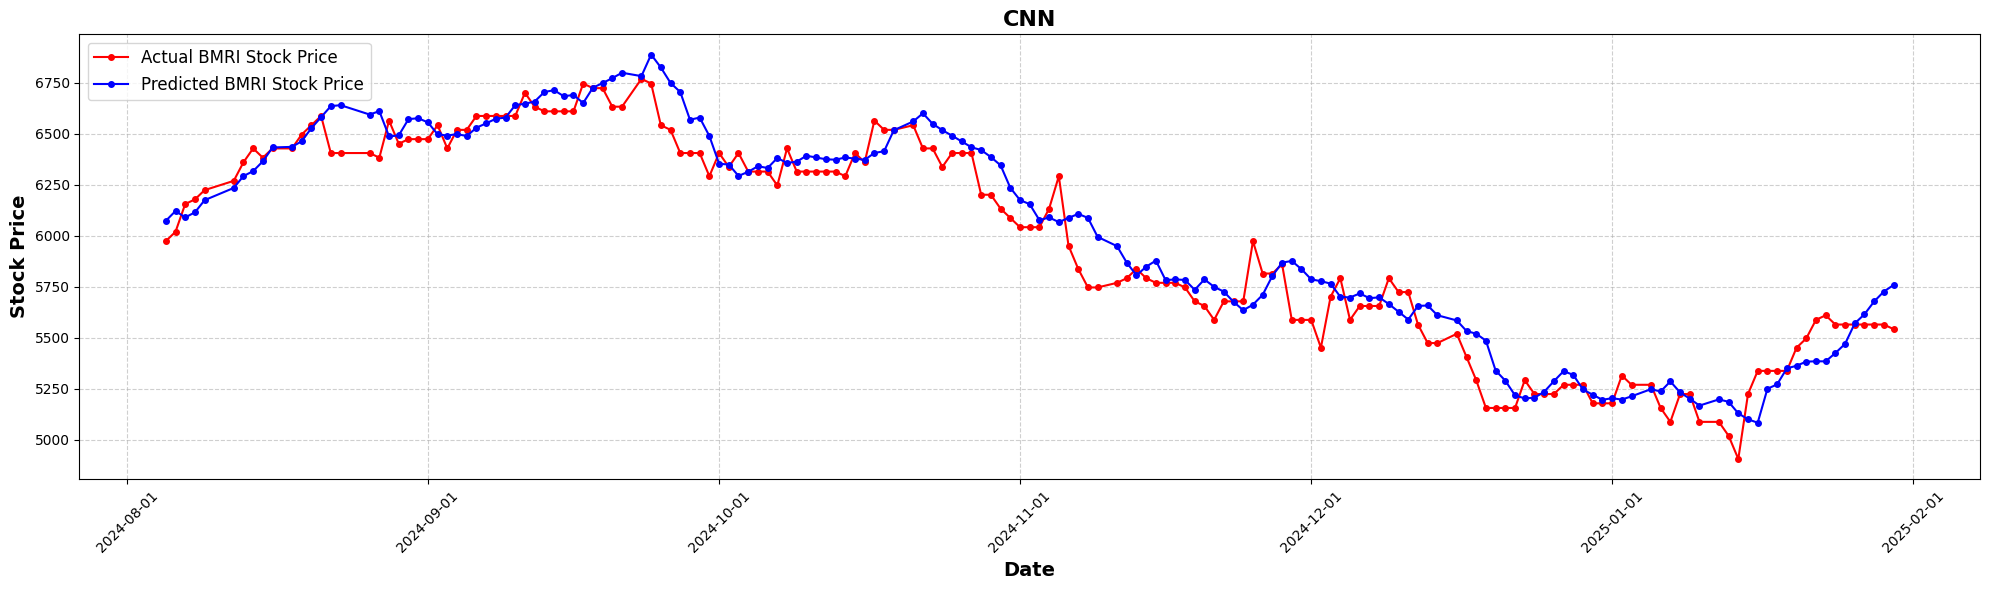

In [132]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Konversi kolom 'Date' ke format datetime jika belum
test_data['Date'] = pd.to_datetime(test_data['Date'])

offset = look_back  # Biasanya 20

# Prediksi hasil model sudah di-inverse transform
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[offset:])

plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BMRI Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BMRI Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("CNN", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


# CNN-LSTM

In [31]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten
from keras.optimizers import Adam
import glob
import re

In [112]:
df = pd.read_csv('data_BMRI.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-02,2563.570068,2589.818226,2537.321911,2589.818226,14460.000000,0.0282,-0.5994
1,2019-01-03,2511.073975,2572.319681,2484.825815,2546.071521,14409.700195,0.0282,0.6361
2,2019-01-04,2607.317383,2607.317383,2502.324737,2511.074124,14375.400391,0.0282,0.6361
3,2019-01-07,2598.567871,2651.064192,2598.567871,2624.816031,14267.000000,0.0282,0.0000
4,2019-01-08,2572.319824,2616.066760,2572.319824,2598.567986,14083.000000,0.0282,0.0000
...,...,...,...,...,...,...,...,...
1868,2025-01-26,5565.121582,5678.695492,5565.121582,5678.695492,16230.900391,0.0076,0.3182
1869,2025-01-27,5565.121582,5678.695492,5565.121582,5678.695492,16164.900391,0.0076,0.3182
1870,2025-01-28,5565.121582,5678.695492,5565.121582,5678.695492,16155.599609,0.0076,0.7797
1871,2025-01-29,5565.121582,5678.695492,5565.121582,5678.695492,15881.200195,0.0076,0.9217


In [113]:
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [114]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size

train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)


In [115]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [116]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [117]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense, Conv1D, LSTM, Flatten

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)

# # Defining hybrid CNN-LSTM model for time series forecasting
n_filters = 128
n_features = len(feature_cols)
kernel_size = 3
model = Sequential()
model.add(Conv1D(filters=n_filters, kernel_size=kernel_size, activation='relu',input_shape=(look_back, n_features)))
model.add(LSTM(64, input_shape=(look_back, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,             
    restore_best_weights=True 
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
81/81 [==============================] - 2s 11ms/step - loss: 0.0065 - val_loss: 0.0101
Epoch 2/100
81/81 [==============================] - 1s 7ms/step - loss: 0.0015 - val_loss: 0.0261
Epoch 3/100
81/81 [==============================] - 1s 7ms/step - loss: 0.0020 - val_loss: 0.0194
Epoch 4/100
81/81 [==============================] - 1s 8ms/step - loss: 0.0020 - val_loss: 0.0217
Epoch 5/100
81/81 [==============================] - 1s 7ms/step - loss: 0.0011 - val_loss: 0.0062
Epoch 6/100
81/81 [==============================] - 1s 8ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 7/100
81/81 [==============================] - 1s 8ms/step - loss: 0.0034 - val_loss: 0.0288
Epoch 8/100
81/81 [==============================] - 1s 8ms/step - loss: 9.1171e-04 - val_loss: 0.0294
Epoch 9/100
81/81 [==============================] - 1s 8ms/step - loss: 0.0010 - val_loss: 0.0050
Epoch 10/100
81/81 [==============================] - 1s 8ms/step - loss: 8.4982e-04 - val_loss: 0.0048


81/81 [==============================] - 1s 8ms/step - loss: 4.9837e-04 - val_loss: 0.0017
Epoch 81/100
81/81 [==============================] - 1s 9ms/step - loss: 3.7887e-04 - val_loss: 0.0041


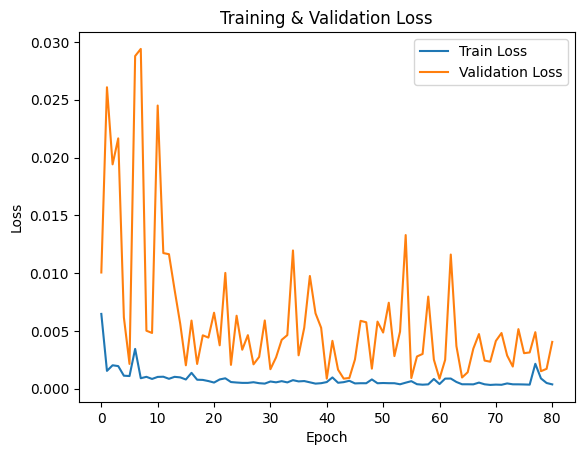

In [118]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()


In [119]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")



11/11 [==============================] - 0s 3ms/step
📊 Evaluation Metrics:
MAE  : 89.3688
MAPE : 1.50%


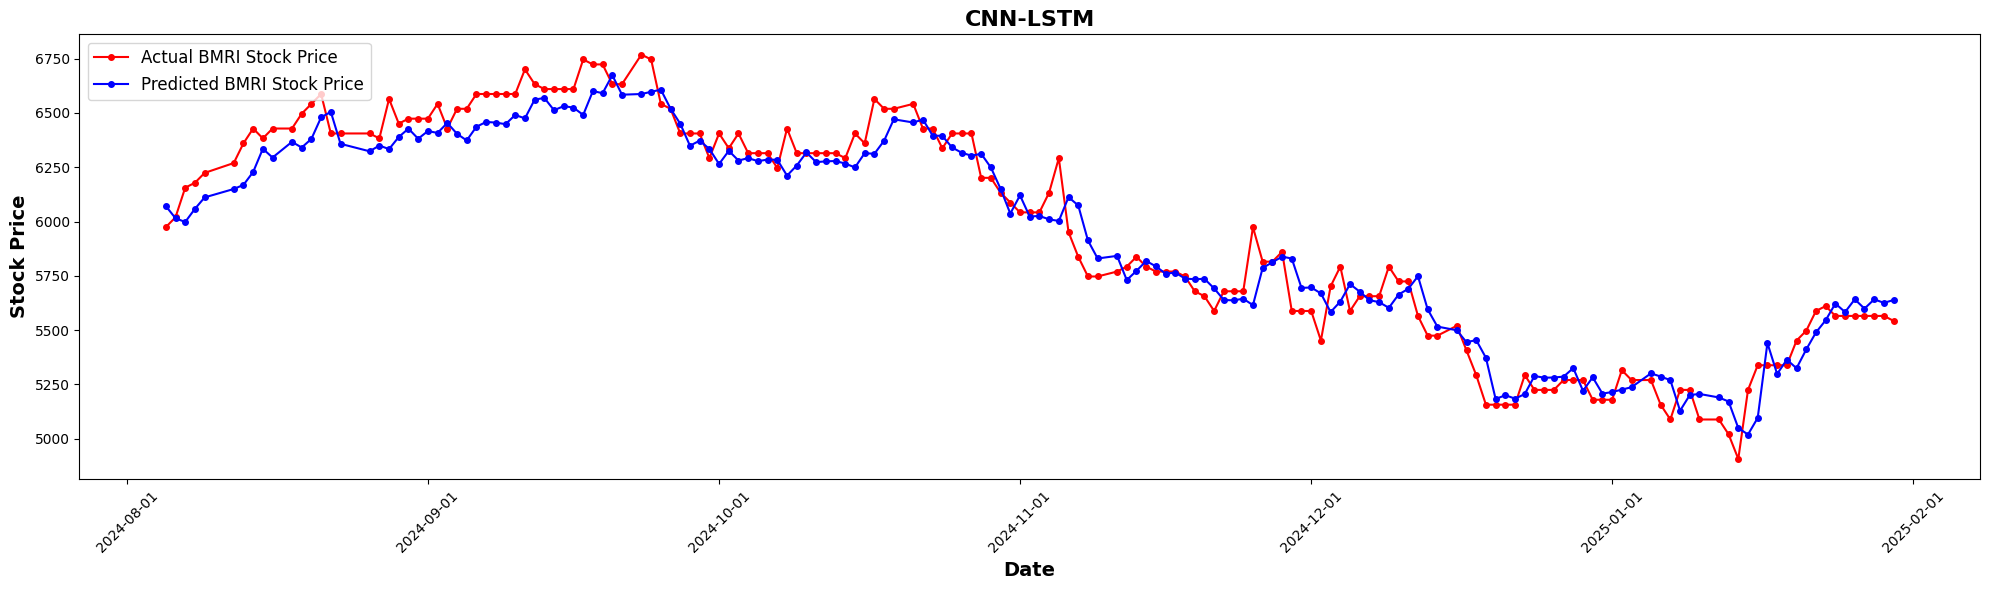

In [120]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Konversi kolom 'Date' ke format datetime jika belum
test_data['Date'] = pd.to_datetime(test_data['Date'])

offset = look_back  # Biasanya 20

# Prediksi hasil model sudah di-inverse transform
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[offset:])

plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BMRI Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BMRI Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("CNN-LSTM", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

# plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()
